# SAVA - Dangerous Object Detection
## Alzheimer Patient Monitoring System

**Project:** SAVA | **Component:** Object Recognition (AI Module)  
**Model:** YOLOv8 | **Purpose:** Detect dangerous objects and alert caregivers

---

### Target Dangerous Object Classes
| Category | Objects |
|---|---|
| Sharp | Knife, Scissors, Razor |
| Medications | Pill bottle, Syringe |
| Chemicals | Spray bottle, Bleach |
| Hot appliances | Iron, Kettle |
| Firearms | Gun (if applicable) |

### Notebook Structure
1. Install Dependencies
2. Import Libraries
3. Configuration
4. Dataset Preparation
5. Data Exploration & Visualization
6. Training
7. Evaluation
8. Inference & Caregiver Alert System
9. Model Export

## 1. Install Dependencies
Run this cell once. Restart the kernel after installation.

In [1]:
# Install all required packages
%pip install ultralytics roboflow fiftyone opencv-python matplotlib seaborn pandas numpy

# Uninstall any existing CPU-only PyTorch first, then install CUDA 12.4 build
# (Compatible with your GTX 1650 / CUDA 12.6 driver)

%pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

  Using cached ultralytics-8.4.38-py3-none-any.whl.metadata (39 kB)
  Using cached roboflow-1.3.3-py3-none-any.whl.metadata (11 kB)
  Using cached fiftyone-1.14.1-py3-none-any.whl.metadata (22 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.2-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached torch-2.11.0-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached opencv_python_headle


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl (2532.4 MB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp311-cp311-win_amd64.whl (6.1 MB)
Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl (4.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [1]:
import os
import json
import shutil
import random
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import torch
from ultralytics import YOLO

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be slow on CPU.")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB


## 3. Configuration
Adjust these settings based on your machine and dataset.

In [13]:
# =============================================
#        PROJECT CONFIGURATION
# =============================================

# Paths
BASE_DIR = Path("../")                     # Root of SAVA project
DATA_DIR = BASE_DIR / "data"               # Dataset storage
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"
MODEL_DIR = BASE_DIR / "models"            # Saved model weights
RUNS_DIR  = BASE_DIR / "runs"              # Training run logs

# Create directories
for d in [DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODEL_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Dangerous object classes for Alzheimer patients
DANGEROUS_CLASSES = [
    "knife",
    "scissors",
    "gun",
    "syringe",
    "bottle",       # can include chemical bottles
    "pill_bottle",
    "razor",
]

CLASS_TO_ID = {cls: idx for idx, cls in enumerate(DANGEROUS_CLASSES)}
ID_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_ID.items()}

# Training hyperparameters
MODEL_SIZE = "yolov8m.pt" # was yolov8m.pt
EPOCHS       = 100
BATCH_SIZE   = 8              # GTX 1650 has 4GB VRAM — keep at 8
IMAGE_SIZE   = 640
CONF_THRESH  = 0.50          # Lower = fewer false negatives (better for safety)
IOU_THRESH   = 0.45
PATIENCE     = 20             # Early stopping patience

print("Configuration loaded.")
print(f"Classes ({len(DANGEROUS_CLASSES)}): {DANGEROUS_CLASSES}")
print(f"Model: {MODEL_SIZE} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE}")

Configuration loaded.
Classes (7): ['knife', 'scissors', 'gun', 'syringe', 'bottle', 'pill_bottle', 'razor']
Model: yolov8m.pt | Epochs: 100 | Batch: 8


In [4]:
OPEN_IMAGES_CLASSES = ["Knife", "Scissors", "Gun", "Syringe"]
TRAIN_IMAGES_DIR = TRAIN_DIR / "images" / "val"
VAL_IMAGES_DIR = VAL_DIR / "images" / "val"

## 4. Dataset Preparation — FiftyOne / Open Images

Downloads 5 of our 7 target classes in a single call from **Google Open Images v7** (free, no account needed).

| Class | Available in Open Images |
|---|---|
| knife, scissors, gun, syringe | ✅ Downloaded automatically |
| bottle | ⛔ Removed — was dominating dataset (97% of samples) |
| razor, pill_bottle | ⚠️ Not in Open Images — add manually via Roboflow later |

> **Note:** `razor` and `pill_bottle` can be added later from [universe.roboflow.com](https://universe.roboflow.com) after the initial model is working.


In [3]:
# =============================================
#   Download from Open Images v7 using FiftyOne
#   No account or API key required.
# =============================================
import fiftyone as fo
import fiftyone.zoo as foz

# Open Images class names (title-cased) that map to our DANGEROUS_CLASSES
# Bottle removed — it dominated the dataset at 97% of all instances
# razor and pill_bottle are not available in Open Images — add via Roboflow later
OPEN_IMAGES_CLASSES = ["Knife", "Scissors", "Gun", "Syringe"]

print(f"Downloading classes: {OPEN_IMAGES_CLASSES}")
print("This may take several minutes on first run...\n")

# Download training split
dataset_train = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=OPEN_IMAGES_CLASSES,
    max_samples=800,           # Increase for better accuracy (start small to test)
    dataset_name="sava_dangerous_train_v2",
)

# Download validation split
dataset_val = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["detections"],
    classes=OPEN_IMAGES_CLASSES,
    max_samples=100,
    dataset_name="sava_dangerous_val_v2",
)

print(f"\nTrain samples: {len(dataset_train)}")
print(f"Val samples:   {len(dataset_val)}")
print("\nNOTE: 'razor' and 'pill_bottle' are not included — model will cover 4/7 classes.")


c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This may take several minutes on first run...

Ignoring invalid classes ['Gun']
You can view the available classes via `fiftyone.utils.openimages.get_classes()`
Necessary images already downloaded
Existing download of split 'train' is sufficient


NoSuchProcess: process PID not found (pid=2372)

In [4]:

# =============================================
#   Export FiftyOne dataset to YOLO format
# =============================================
import fiftyone as fo
import os

# Auto-detect the actual label field name in the cached dataset
sample = dataset_train.first()
label_field = None
for fname in sample.field_names:
    try:
        val = sample[fname]
        if isinstance(val, fo.Detections):
            label_field = fname
            break
    except Exception:
        pass

if label_field is None:
    print("WARNING: No Detections field found. Available fields:")
    print([f for f in sample.field_names if f not in ("id", "filepath", "metadata", "tags")])
    raise RuntimeError("Cannot export — no detections field found in dataset.")

print(f"Using label field: '{label_field}'")

# Export training set
dataset_train.export(
    export_dir=str(TRAIN_DIR),
    dataset_type=fo.types.YOLOv5Dataset,
    label_field=label_field,
    classes=OPEN_IMAGES_CLASSES,
    overwrite=True,
)

# Export validation set
dataset_val.export(
    export_dir=str(VAL_DIR),
    dataset_type=fo.types.YOLOv5Dataset,
    label_field=label_field,
    classes=OPEN_IMAGES_CLASSES,
    overwrite=True,
)

print("Datasets exported to YOLO format.")

# ---- Resolve actual label/image directories ----
# FiftyOne YOLOv5 export nests files under a split-named subfolder, e.g.:
#   TRAIN_DIR/images/val/  and  TRAIN_DIR/labels/val/
all_train_labels = list(TRAIN_DIR.rglob("labels/**/*.txt"))
all_val_labels   = list(VAL_DIR.rglob("labels/**/*.txt"))

if not all_train_labels:
    raise RuntimeError("No label .txt files found under TRAIN_DIR after export!")

# e.g.  ..\data\train\labels\val
TRAIN_LABELS_DIR = all_train_labels[0].parent
VAL_LABELS_DIR   = all_val_labels[0].parent if all_val_labels else None

# Corresponding images folder: swap 'labels' segment for 'images', keep same leaf name
# ..\data\train\labels\val  ->  ..\data\train\images\val
TRAIN_IMAGES_DIR = TRAIN_LABELS_DIR.parent.parent / "images" / TRAIN_LABELS_DIR.name
VAL_IMAGES_DIR   = VAL_LABELS_DIR.parent.parent / "images" / VAL_LABELS_DIR.name if VAL_LABELS_DIR else None

print(f"\nTrain labels : {TRAIN_LABELS_DIR}  ({len(all_train_labels)} files)")
print(f"Train images : {TRAIN_IMAGES_DIR}  (exists={TRAIN_IMAGES_DIR.exists()})")
print(f"Val   labels : {VAL_LABELS_DIR}  ({len(all_val_labels)} files)")
print(f"Val   images : {VAL_IMAGES_DIR}  (exists={VAL_IMAGES_DIR.exists() if VAL_IMAGES_DIR else False})")


Using label field: 'ground_truth'


c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Dagger' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Human hand' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Kitchen knife' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Orange' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Grapefruit' not in provided classes
  warnings.warn(msg)
c:\Us

c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Clock' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Computer monitor' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Wheel' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Tire' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Dessert' not in provided classes
  warnings.warn(msg)
c:\Users\Neza

  22% |███/-------------| 108/500 [516.7ms elapsed, 1.9s remaining, 209.0 samples/s] 

c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Toilet paper' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Table' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Clothing' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Plant' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Watch' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\

...

c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Tomato' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Snack' not in provided classes
  warnings.warn(msg)


 100% |█████████████████| 500/500 [2.3s elapsed, 0s remaining, 220.7 samples/s]      
  35% |██████/------------| 21/60 [109.6ms elapsed, 203.5ms remaining, 191.7 samples/s] 

c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Bagel' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Bread' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Tool' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Kitchen utensil' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Radish' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\

 100% |███████████████████| 60/60 [311.9ms elapsed, 0s remaining, 192.3 samples/s]      
Datasets exported to YOLO format.

Train labels : ..\data\train\labels\val  (500 files)
Train images : ..\data\train\images\val  (exists=True)
Val   labels : ..\data\val\labels\val  (60 files)
Val   images : ..\data\val\images\val  (exists=True)


c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Human body' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Mammal' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Coin' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Human head' not in provided classes
  warnings.warn(msg)
c:\Users\Nezar\AppData\Local\Programs\Python\Python311\Lib\site-packages\fiftyone\utils\yolo.py:1154: UserWarning: Ignoring object with label 'Handgun' not in provided classes
  warnings.warn(msg)
c:\Users\Neza

## 5. Data Exploration & Visualization
Understand your dataset before training.

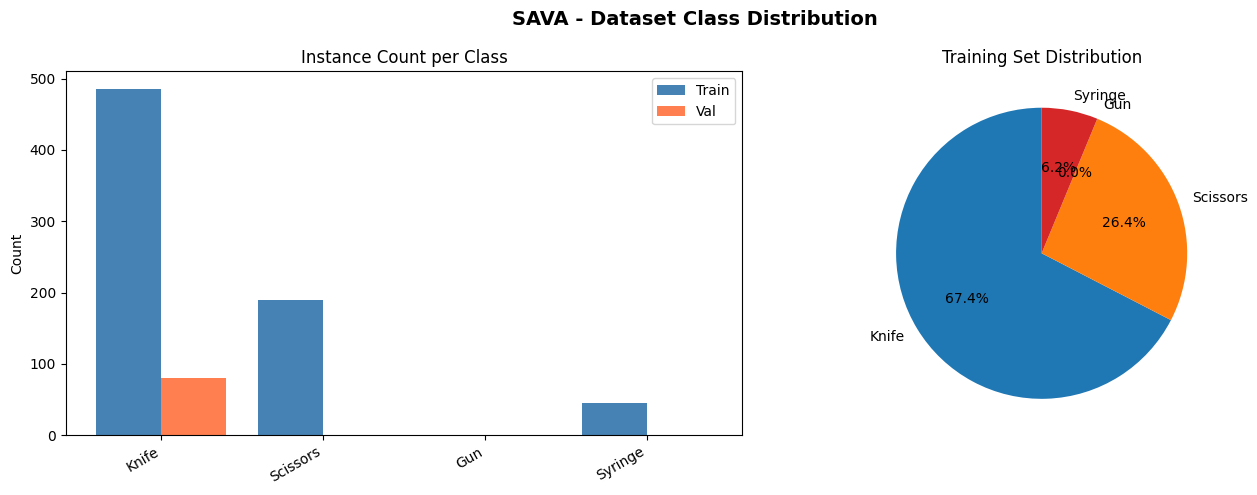

   Class  Train  Val
   Knife    486   80
Scissors    190    1
     Gun      0    0
 Syringe     45    0


In [5]:

# Use the classes that were actually exported — Open Images order
ACTIVE_CLASSES = OPEN_IMAGES_CLASSES  # ["Knife", "Scissors", "Gun", "Bottle", "Syringe"]

def count_labels(label_dir: Path, classes: list) -> dict:
    """Count instances of each class in a YOLO label directory."""
    counts = {cls: 0 for cls in classes}
    for lf in label_dir.glob("*.txt"):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    if class_id < len(classes):
                        counts[classes[class_id]] += 1
    return counts


# Use paths resolved by the export cell
if TRAIN_LABELS_DIR is None or not TRAIN_LABELS_DIR.exists():
    print("Label directory not found. Run the export cell first.")
else:
    train_counts = count_labels(TRAIN_LABELS_DIR, ACTIVE_CLASSES)
    val_counts   = count_labels(VAL_LABELS_DIR,   ACTIVE_CLASSES) if VAL_LABELS_DIR and VAL_LABELS_DIR.exists() else {c: 0 for c in ACTIVE_CLASSES}

    df = pd.DataFrame({
        "Class": list(train_counts.keys()),
        "Train": list(train_counts.values()),
        "Val":   list(val_counts.values()),
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("SAVA - Dataset Class Distribution", fontsize=14, fontweight="bold")

    # Bar chart
    x = range(len(df))
    axes[0].bar([i - 0.2 for i in x], df["Train"], width=0.4, label="Train", color="steelblue")
    axes[0].bar([i + 0.2 for i in x], df["Val"],   width=0.4, label="Val",   color="coral")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["Class"], rotation=30, ha="right")
    axes[0].set_title("Instance Count per Class")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Pie chart — only draw if there is at least some data
    train_vals = df["Train"].values
    if train_vals.sum() > 0:
        axes[1].pie(train_vals, labels=df["Class"], autopct="%1.1f%%", startangle=90)
        axes[1].set_title("Training Set Distribution")
    else:
        axes[1].text(0.5, 0.5, "No labelled data found", ha="center", va="center")
        axes[1].set_title("Training Set Distribution")

    plt.tight_layout()
    plt.savefig(str(BASE_DIR / "runs" / "class_distribution.png"), dpi=150)
    plt.show()
    print(df.to_string(index=False))


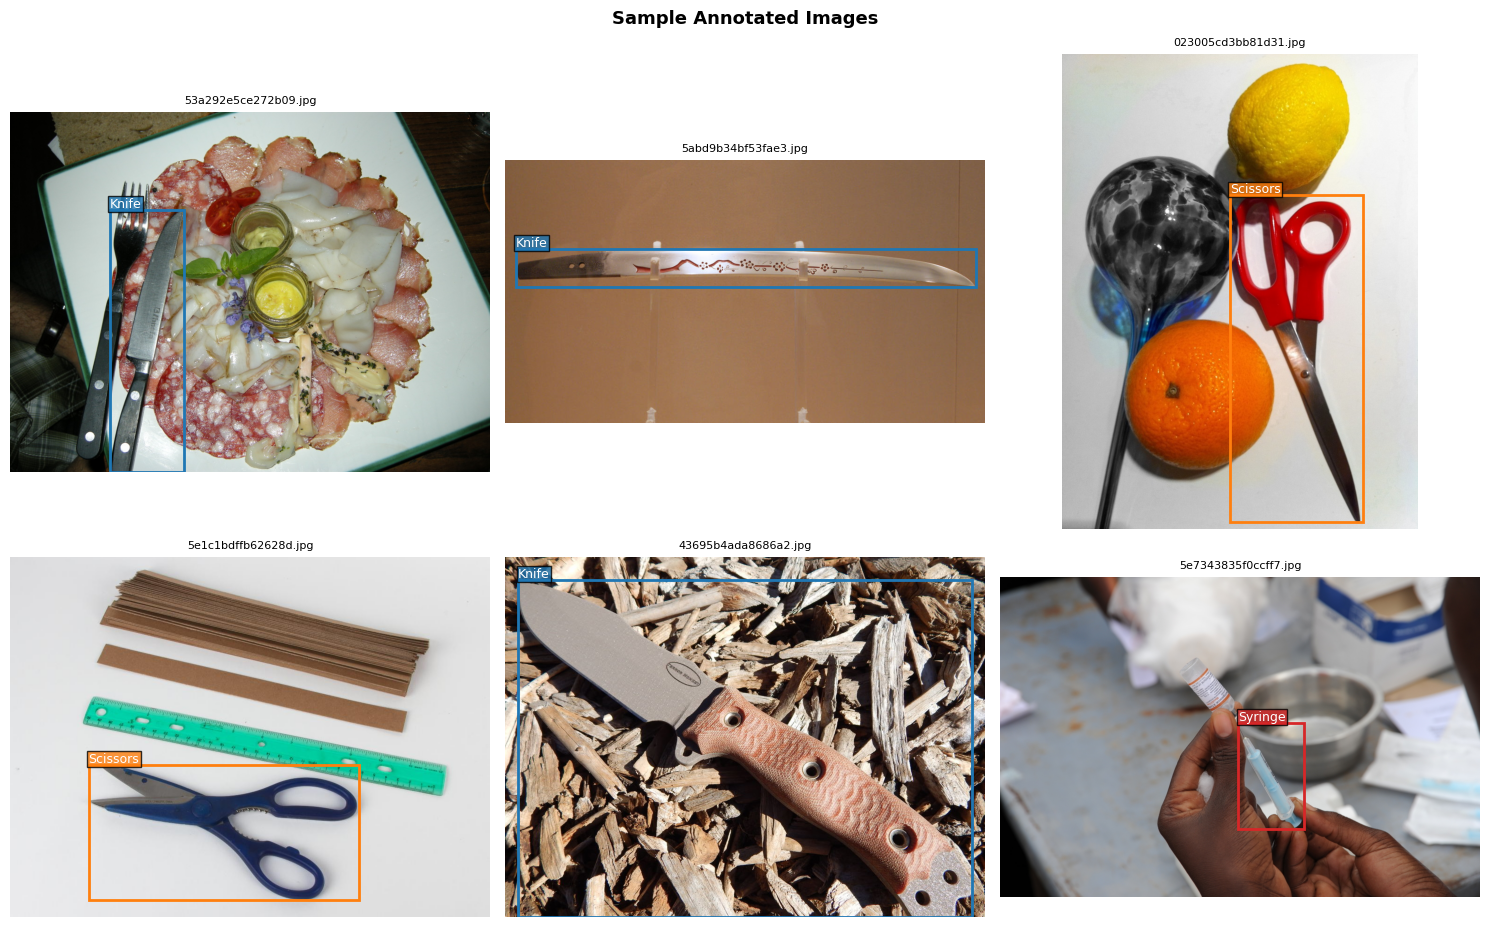

In [6]:

def visualize_sample_images(img_dir: Path, label_dir: Path, n: int = 6):
    """Display sample images with bounding box annotations."""
    img_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    if not img_files:
        print("No images found.")
        return

    samples = random.sample(img_files, min(n, len(img_files)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    colors = plt.cm.tab10.colors

    for ax, img_path in zip(axes, samples):
        img = np.array(Image.open(img_path).convert("RGB"))
        h, w = img.shape[:2]
        ax.imshow(img)

        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        cx, cy, bw, bh = map(float, parts[1:])
                        x1 = (cx - bw / 2) * w
                        y1 = (cy - bh / 2) * h
                        rect = patches.Rectangle(
                            (x1, y1), bw * w, bh * h,
                            linewidth=2, edgecolor=colors[cls_id % 10], facecolor="none"
                        )
                        ax.add_patch(rect)
                        label = ACTIVE_CLASSES[cls_id] if cls_id < len(ACTIVE_CLASSES) else str(cls_id)
                        ax.text(x1, y1 - 5, label, color="white", fontsize=9,
                                bbox=dict(facecolor=colors[cls_id % 10], alpha=0.8, pad=1))

        ax.axis("off")
        ax.set_title(img_path.name, fontsize=8)

    plt.suptitle("Sample Annotated Images", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


if TRAIN_IMAGES_DIR and TRAIN_IMAGES_DIR.exists():
    visualize_sample_images(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
else:
    print("Images not found. Run the export cell first.")


## 6. YAML Configuration File
YOLOv8 requires a `.yaml` file describing your dataset structure.

In [5]:

import yaml

# Use the actual image paths resolved from the export structure
dataset_yaml = {
    "path": str(DATA_DIR.resolve()),
    "train": str(TRAIN_IMAGES_DIR.resolve()),
    "val":   str(VAL_IMAGES_DIR.resolve()),
    "nc":    len(OPEN_IMAGES_CLASSES),
    "names": [c.lower() for c in OPEN_IMAGES_CLASSES],
}

yaml_path = DATA_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print(f"Dataset YAML saved to: {yaml_path}")
print("\nContent:")
with open(yaml_path) as f:
    print(f.read())


Dataset YAML saved to: ..\data\dataset.yaml

Content:
path: C:\Users\Nezar\Downloads\Object detection\data
train: C:\Users\Nezar\Downloads\Object detection\data\train\images\val
val: C:\Users\Nezar\Downloads\Object detection\data\val\images\val
nc: 4
names:
- knife
- scissors
- gun
- syringe



## 7. Model Training

We use **YOLOv8** with transfer learning from COCO pre-trained weights.  
This significantly reduces training time and improves accuracy.

In [5]:
# Load pre-trained YOLOv8 model (downloads weights automatically on first run)
model = YOLO(MODEL_SIZE)
print(f"Model loaded: {MODEL_SIZE}")
print(f"Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

Model loaded: yolov8m.pt
Parameters: 25,902,640


In [9]:
# =============================================
#            TRAIN THE MODEL
# =============================================
# This cell will take a while to run depending on your hardware.
# GPU: ~20-40 min | CPU: several hours

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,           # Early stopping
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    workers=0,
    project=str(RUNS_DIR),
    name="sava_dangerous_objects",
    exist_ok=True,
    plots=True,                  # Auto-generate training plots
    save=True,
    save_period=10,              # Save checkpoint every 10 epochs
    # Augmentation (helps generalize to home environments)
    flipud=0.1,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)

print("\nTraining complete!")
print(f"Best weights saved to: {RUNS_DIR}/sava_dangerous_objects/weights/best.pt")

Ultralytics 8.4.38  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.4, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\data\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sava_dangerous_objects, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

## 8. Evaluation
Measure how well the model performs. **Focus on Recall** — we want to catch all dangerous objects.

In [6]:

# Load best trained weights
best_weights = RUNS_DIR / "runs" / "sava_dangerous_objects" / "weights" / "best.pt"
model_eval = YOLO(str(best_weights))

# Run validation
val_results = model_eval.val(
    data=str(yaml_path),
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    plots=True,
)

print("\n=== EVALUATION RESULTS ===")
print(f"mAP@50:     {val_results.box.map50:.4f}")
print(f"mAP@50-95:  {val_results.box.map:.4f}")
print(f"Precision:  {val_results.box.mp:.4f}")
print(f"Recall:     {val_results.box.mr:.4f}")
print("\nPer-class results:")
eval_classes = [c.lower() for c in OPEN_IMAGES_CLASSES]
for i, cls in enumerate(eval_classes):
    if i < len(val_results.box.ap50):
        print(f"  {cls:<15} AP50: {val_results.box.ap50[i]:.4f}")


Ultralytics 8.4.38  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 333.5105.4 MB/s, size: 280.2 KB)
val: Scanning C:\Users\Nezar\Downloads\Object detection\data\val\labels\val.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.5s1.1ss
                   all         60         81      0.903      0.865      0.898      0.799
                 knife         59         80      0.967       0.73      0.802      0.603
              scissors          1          1      0.838          1      0.995      0.995
Speed: 5.1ms preprocess, 24.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to C:\Users\Nezar\Downloads\Object detection\Object detection\runs\detect\val6

=== EV

In [7]:
# Visualize training curves from the results CSV
results_csv = RUNS_DIR / "sava_dangerous_objects" / "results.csv"

if results_csv.exists():
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("Training Curves - SAVA Dangerous Object Detection", fontsize=14, fontweight="bold")

    metrics = [
        ("train/box_loss",  "Train Box Loss",  "steelblue"),
        ("train/cls_loss",  "Train Class Loss", "tomato"),
        ("val/box_loss",    "Val Box Loss",    "darkorange"),
        ("metrics/mAP50",   "mAP@50",          "green"),
        ("metrics/precision", "Precision",     "purple"),
        ("metrics/recall",  "Recall",          "brown"),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), metrics):
        if col in df_results.columns:
            ax.plot(df_results["epoch"], df_results[col], color=color, linewidth=2)
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(RUNS_DIR / "training_curves.png"), dpi=150)
    plt.show()
else:
    print("Results CSV not found. Run training first.")

Results CSV not found. Run training first.


## 9. Inference & Caregiver Alert System
Run the model on new images/video feed and trigger alerts when dangerous objects are detected.

In [7]:
import logging

# =============================================
#      ALERT CONFIGURATION
# =============================================
# Map class names to danger severity
DANGER_LEVELS = {
    "knife":       "HIGH",
    "gun":         "HIGH",
    "syringe":     "HIGH",
    "scissors":    "MEDIUM",
    "razor":       "HIGH",
    "pill_bottle": "MEDIUM",
    "bottle":      "LOW",
}

ALERT_LOG_PATH = RUNS_DIR / "alert_log.json"
alerts = []


def log_alert(class_name: str, confidence: float, bbox: list, source: str = "camera"):
    """Log a detection alert with timestamp."""
    level = DANGER_LEVELS.get(class_name, "LOW")
    alert = {
        "timestamp":  datetime.now().isoformat(),
        "object":     class_name,
        "danger":     level,
        "confidence": round(confidence, 3),
        "bbox":       bbox,
        "source":     source,
    }
    alerts.append(alert)

    # Save to log file
    with open(ALERT_LOG_PATH, "w") as f:
        json.dump(alerts, f, indent=2)

    print(f"[ALERT - {level}] Detected '{class_name}' with {confidence:.1%} confidence at {alert['timestamp']}")
    return alert


print("Alert system initialized.")

Alert system initialized.


In [8]:
def run_inference_on_image(image_path: str, show: bool = True):
    """
    Run dangerous object detection on a single image.
    Logs alerts for any detections above confidence threshold.
    """
    results = model_eval.predict(
        source=image_path,
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        save=False,
        verbose=False,
    )

    result = results[0]
    detections = []

    for box in result.boxes:
        cls_id   = int(box.cls[0])
        conf     = float(box.conf[0])
        bbox     = box.xyxy[0].tolist()
        cls_name = ID_TO_CLASS.get(cls_id, "unknown")

        alert = log_alert(cls_name, conf, bbox, source=image_path)
        detections.append(alert)

    if show:
        img = result.plot()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 7))
        plt.imshow(img_rgb)
        plt.axis("off")
        title = f"Detections: {len(detections)} | Source: {Path(image_path).name}"
        plt.title(title, fontsize=12)
        plt.tight_layout()
        plt.show()

    return detections


# --- Test on an image ---
# Replace with a real image path to test
# test_image = "path/to/your/test_image.jpg"
# detections = run_inference_on_image(test_image)

print("Inference function ready. Provide an image path to test.")

Inference function ready. Provide an image path to test.


In [9]:
def run_inference_on_video(video_source=0):
    """
    Run detection on a live camera feed or video file indefinitely.
    video_source: 0 = webcam, or path to a video file.
    Press Q to quit.
    """
    cap = cv2.VideoCapture(video_source)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    
    if not cap.isOpened():
        print("ERROR: Cannot open video source.")
        return

    frame_count = 0
    print("Starting video inference. Press Q to quit.")

    while True:
        ret, frame = cap.read()
        
        if not ret:
            continue

        results = model_eval.predict(source=frame, conf=CONF_THRESH, verbose=False)
        annotated = results[0].plot()

        for box in results[0].boxes:
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            cls_name = ID_TO_CLASS.get(cls_id, "unknown")
            log_alert(cls_name, conf, box.xyxy[0].tolist(), source="video_feed")

        cv2.imshow("SAVA - Dangerous Object Detection", annotated)
        frame_count += 1

        if cv2.waitKey(10) & 0xFF == ord("q"):
            print("Quitting...")
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"Processed {frame_count} frames. Total alerts: {len(alerts)}")

## 10. Export Model for Deployment
Export the trained model to ONNX or TFLite format for deployment on IoT devices.

In [8]:
import shutil
import os
from pathlib import Path
from ultralytics import YOLO

# 1. RE-DEFINE VARIABLES (In case the kernel was restarted)
# Use the exact path we found earlier
true_best_weights = r"C:\Users\Nezar\Downloads\Object detection\Object detection\runs\runs\sava_dangerous_objects\weights\best.pt"
MODEL_DIR = Path("models")
IMAGE_SIZE = 640  # Standard YOLO size

# 2. LOAD THE MODEL
print("Loading model...")
model_eval = YOLO(true_best_weights)

# 3. MAKE SURE MODELS FOLDER EXISTS
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 4. EXPORT TO ONNX
print("Starting ONNX export...")
model_eval.export(format="onnx", imgsz=IMAGE_SIZE, simplify=True)
print("✅ Exported to ONNX format.")

# 5. COPY THE BEST WEIGHTS
destination = MODEL_DIR / "sava_dangerous_best.pt"
shutil.copy(true_best_weights, str(destination))

print(f"✅ Best weights copied to: {destination}")
print("\n--- DEPLOYMENT READY ---")

Loading model...
Starting ONNX export...
Ultralytics 8.4.38  Python-3.11.9 torch-2.6.0+cu124 CPU (AMD Ryzen 7 5800H with Radeon Graphics)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'C:\Users\Nezar\Downloads\Object detection\Object detection\runs\runs\sava_dangerous_objects\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (49.6 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success  2.5s, saved as 'C:\Users\Nezar\Downloads\Object detection\Object detection\runs\runs\sava_dangerous_objects\weights\best.onnx' (98.8 MB)

Export complete (3.5s)
Results saved to C:\Users\Nezar\Downloads\Object detection\Object detection\runs\runs\sava_dangerous_objects\weights
Predict:         yolo predict task=detect model=C:\Users\Nezar\Downloads\Object detection\Object detection\runs\runs\sava_dangerous_objects\weights\best.onnx imgsz=640 
Vali

## 11. Alert Log Review
View all alerts generated during this session.

In [19]:
if ALERT_LOG_PATH.exists():
    with open(ALERT_LOG_PATH) as f:
        all_alerts = json.load(f)

    df_alerts = pd.DataFrame(all_alerts)
    print(f"Total alerts: {len(df_alerts)}\n")
    print(df_alerts[["timestamp", "object", "danger", "confidence"]].to_string(index=False))

    # Summary by danger level
    print("\nAlert Summary by Danger Level:")
    print(df_alerts.groupby("danger")["object"].count().sort_values(ascending=False))
else:
    print("No alerts logged yet. Run inference on images/video first.")

No alerts logged yet. Run inference on images/video first.


12. testing

In [13]:
run_inference_on_image("C:/Users/Nezar/Pictures/Screenshots/Screenshot 2026-04-17 225902.png", show=True)

[ALERT - HIGH] Detected 'knife' with 68.5% confidence at 2026-04-18T00:20:44.996426


<Figure size 1000x700 with 1 Axes>

[{'timestamp': '2026-04-18T00:20:44.996426',
  'object': 'knife',
  'danger': 'HIGH',
  'confidence': 0.685,
  'bbox': [141.70521545410156,
   32.116676330566406,
   193.09735107421875,
   296.15081787109375],
  'source': 'C:/Users/Nezar/Pictures/Screenshots/Screenshot 2026-04-17 225902.png'}]

In [14]:
run_inference_on_video(video_source=0)

Starting video inference. Press Q to quit.
[ALERT - HIGH] Detected 'knife' with 50.5% confidence at 2026-04-18T02:20:40.459992
[ALERT - HIGH] Detected 'knife' with 55.8% confidence at 2026-04-18T02:20:40.614556
[ALERT - HIGH] Detected 'knife' with 52.4% confidence at 2026-04-18T02:20:40.914024
[ALERT - HIGH] Detected 'knife' with 54.0% confidence at 2026-04-18T02:20:40.975726
[ALERT - HIGH] Detected 'knife' with 50.7% confidence at 2026-04-18T02:20:41.037535
[ALERT - HIGH] Detected 'knife' with 52.5% confidence at 2026-04-18T02:20:41.238384
[ALERT - HIGH] Detected 'knife' with 52.2% confidence at 2026-04-18T02:20:41.347702
[ALERT - HIGH] Detected 'knife' with 56.0% confidence at 2026-04-18T02:20:41.411048
[ALERT - HIGH] Detected 'knife' with 54.2% confidence at 2026-04-18T02:20:41.429289
[ALERT - HIGH] Detected 'knife' with 50.4% confidence at 2026-04-18T02:20:41.489071
[ALERT - HIGH] Detected 'knife' with 51.7% confidence at 2026-04-18T02:20:41.550197
[ALERT - HIGH] Detected 'knife' w